# Bilateral decoding of position from spike counts using a Poisson Bayesian Decoder

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
from scipy.interpolate import interp1d
from scipy.special import logsumexp
import os
from core import *

In [57]:
# ----------------------------- Config ---------------------------------

# Data paths and session info
DATA_DIR = r"\\research-cifs.nyumc.org\research\buzsakilab\Homes\voerom01\Bilat_HPC\Bilat_R02\Bilat_R02_20251106"
FIG_DIR = r"\\research-cifs.nyumc.org\research\buzsakilab\Homes\voerom01\Bilat_HPC\Bilat_R02\Bilat_R02_20251106\analysisFigures"
SESSION_NAME = "pre_sleep_g0"
BASE_NAME = "Bilat_R02_20251106"
PROBES = [0, 1, 2, 3]


# Spike rate computation parameters
WINDOW_SIZE = 0.01         # s
STEP_SIZE   = 0.01        # s
USE_UNITS   = "good"       # {'all', 'good', 'mua'}


# Filtering thresholds
MIN_TOTAL_SPIKES   = 500
MIN_MEAN_RATE_HZ   = .01
MIN_PRESENCE_RATIO = 0.75
N_TIME_BINS        = 100    # coarse bins for presence ratio


# defining the region dictionary. Keys are probe numbers, values are dictionaries which are further mapping shanks to regions
#region_dict = {0: {0: 'CA1', 1: 'RSP', 2: 'CA3', 3: 'CA1', 4: 'RSP', 5: 'CA3', 6: 'CA1', 7: 'RSP'}, 1: {0: 'CA3', 1: 'CA1', 2: 'CA2', 3: 'A1', 4: 'S1'}, 2: {0: 'CA3', 1: 'Th', 2: 'V1', 3: 'Th', 4: 'CA1', 5: 'V1', 6: 'CA1', 7: 'V1'}} UDS
region_dict = {
    0: {0: 'CA1', 1: 'Th', 2: 'CA1', 3: 'CA1', 4: 'CA1', 5: 'CA1', 6: 'CA1', 7: 'CA1'},
    1: {0: 'CA1', 1: 'CA1', 2: 'CA1', 3: 'CA1', 4: 'CA1', 5: 'CA1', 6: 'CA1', 7: 'CA1'},
    2: {0: 'CA1', 1: 'CA1', 2: 'CA1', 3: 'CA1', 4: 'CA1', 5: 'CA1', 6:'CA1'}, 
    3: {0: 'CA1', 1: 'CA1', 2: 'CA1', 3: 'CA1', 4: 'CA1', 5: 'CA1', 6: 'CA1', 7: 'CA1'}
}


# defining the hemisphere dictionary. Keys are probe numbers, values are 'L' or 'R' for left/right hemisphere
hemisphere_dict = {0: 'L', 1: 'L', 2: 'R', 3: 'R'}

# Create figure directory if it doesn't exist
os.makedirs(FIG_DIR, exist_ok=True)

In [58]:
# ------------------------ Load spike rate matrices ------------------------
spike_count_matrices = {}
cell_types = {}
regions = {}
for probe in PROBES:
    # Get the raw spike counts and the zscored and smoothed spike rates
    ks_dir = os.path.join(DATA_DIR, f'Kilosort_imec{probe}_ks4')
    spike_count_matrix, time_bins, units = compute_spike_counts(str(ks_dir), WINDOW_SIZE, STEP_SIZE, USE_UNITS, 0.0, False, adj = '_sec_adj')


    # computing the filtering metrics
    total_spikes   = spike_count_matrix.sum(axis=1)         
    mean_rates   = spike_count_matrix.mean(axis=1) / WINDOW_SIZE
    presence_ratio = get_presence_ratio(spike_count_matrix, time_bins, N_TIME_BINS)

    mask = (
        (total_spikes >= MIN_TOTAL_SPIKES) &
        (mean_rates >= MIN_MEAN_RATE_HZ) &
        (presence_ratio >= MIN_PRESENCE_RATIO)
    )


    # Apply mask to spike rate matrix and unit list
    spike_count_matrix = spike_count_matrix[mask, :]
    units = [u for u, keep in zip(units, mask) if keep]
    print(f"Probe {probe}: Keeping {mask.sum()} / {mask.sum() + (~mask).sum()} units after filtering.\nspike_count_matrix shape: {spike_count_matrix.shape}\n")

    # remove units based on presence ratio
    spike_count_matrices[probe] = (spike_count_matrix, time_bins, units)


    # Load the cell metrics
    cell_metrics_file = os.path.join(DATA_DIR, f'{BASE_NAME}_imec{probe}.cell_metrics.cellinfo.mat')
    cell_type = loadmat(cell_metrics_file)['cell_metrics']['putativeCellType'][0,0].flatten()
    shank_ids = loadmat(cell_metrics_file)['cell_metrics']['shankID'][0,0].flatten()


    # keeping only the string labels
    cell_type = np.array([ct[0] if isinstance(ct, np.ndarray) else ct for ct in cell_type])

    # removing mask applied units from cell type
    cell_types[probe] = cell_type[mask]
    regions[probe] = np.array([region_dict[probe][shank_id-1] for shank_id in shank_ids[mask]])  # shank IDs are 1-based

Probe 0: Keeping 74 / 80 units after filtering.
spike_count_matrix shape: (74, 1052094)

Probe 1: Keeping 45 / 49 units after filtering.
spike_count_matrix shape: (45, 1052094)

Probe 2: Keeping 269 / 299 units after filtering.
spike_count_matrix shape: (269, 1052094)

Probe 3: Keeping 289 / 305 units after filtering.
spike_count_matrix shape: (289, 1052094)



Number of frames: 308232
first row of tracking data: [ 0.00000e+00  0.00000e+00  6.81780e-02 -1.61595e-01 -9.67768e-01
 -1.80732e-01 -1.07200e-03  2.23371e-01  5.83550e-02  4.13000e-04]
Trimming TTLs from 308285 to 308232
Tracking start time: 3926.353 s, end time: 6494.814 s, duration: 2568.461 s


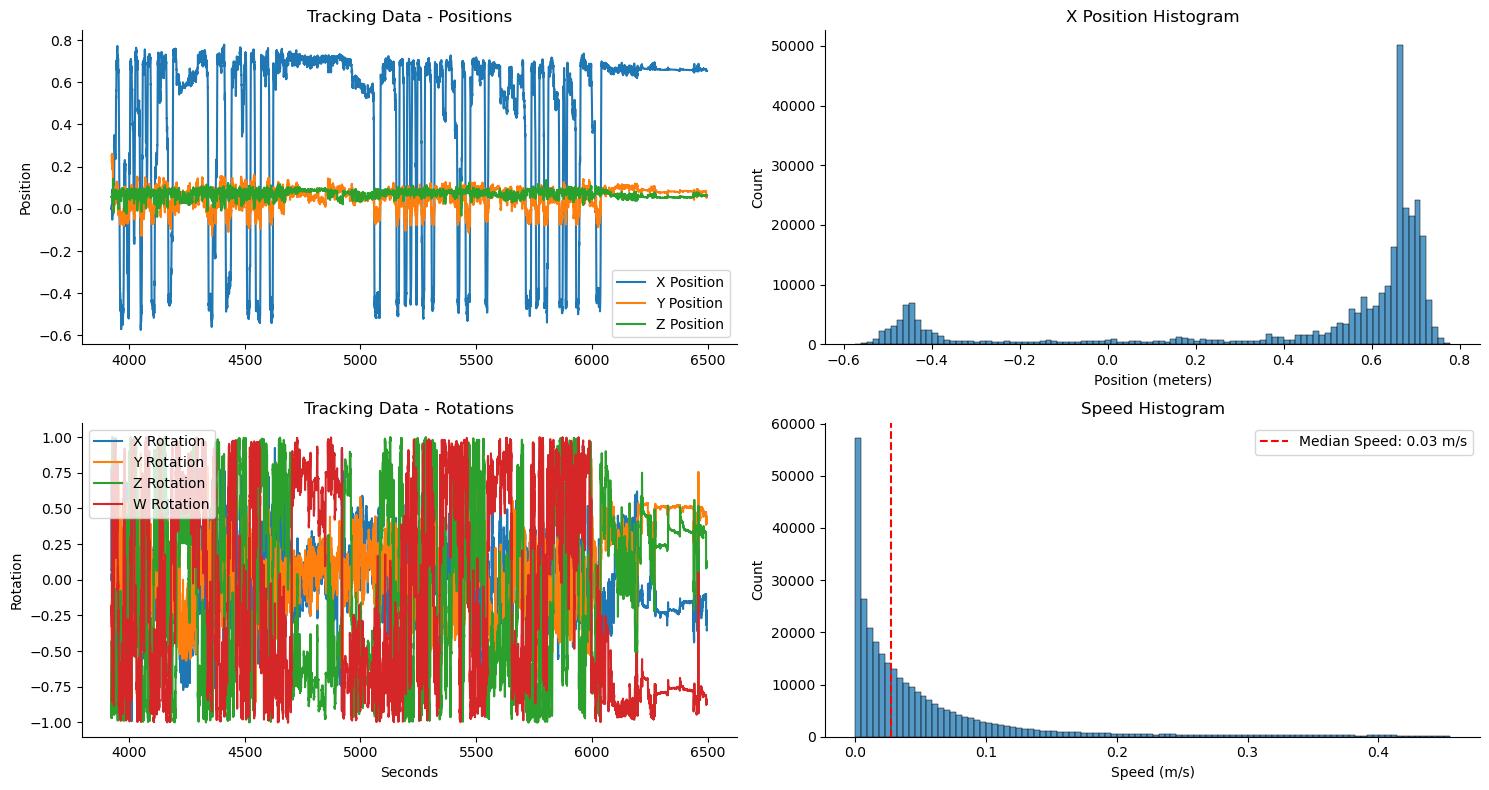

In [59]:
use_position = 'x'  # 'x', 'y', or 'z'

# Loading the manually extracted TTL times
manual_ttl_file = os.path.join(DATA_DIR, 'manual_ttl_extraction.csv')
manual_ttls_df = pd.read_csv(manual_ttl_file)
ttls = manual_ttls_df['ttl_times_sec'].values

# Loadding in the tracking data
tracking_file = os.path.join(DATA_DIR, "Bilat_R02_20251106_linear_maze_000.csv")
tracking_data = np.genfromtxt(tracking_file, delimiter=",", skip_header=7)
frames = tracking_data[:,0]
print(f'Number of frames: {len(frames)}')
print(f'first row of tracking data: {tracking_data[0,:]}')


# Sometimes there are a few more frames after the last TTL or more TTLs than frames. We will trim the data to the shortest length.
if len(frames) < len(ttls):
    print(f'Trimming TTLs from {len(ttls)} to {len(frames)}')
    ttls = ttls[:len(frames)]
    tracking_data = tracking_data[:len(frames),:]
elif len(frames) > len(ttls):
    print(f'Trimming frames from {len(frames)} to {len(ttls)}')
    frames = frames[:len(ttls)]
    tracking_data = tracking_data[:len(ttls),:]

# printing the start and end times
print(f'Tracking start time: {ttls[0]:.3f} s, end time: {ttls[-1]:.3f} s, duration: {ttls[-1]-ttls[0]:.3f} s')


# fill missing values or nan with linear interpolation
for i in range(tracking_data.shape[1]):
    col = tracking_data[:,i]
    nans = np.isnan(col)
    if np.any(nans):
        not_nans = ~nans
        interp_func_col = interp1d(frames[not_nans], col[not_nans], bounds_error=False, fill_value="extrapolate")
        col[nans] = interp_func_col(frames[nans])
        tracking_data[:,i] = col

# extract x, y, z positions and rotations
x_rotations = tracking_data[:,2]
y_rotations = tracking_data[:,3]
z_rotations = tracking_data[:,4]
w_rotations = tracking_data[:,5]
x_positions = tracking_data[:,6]
y_positions = tracking_data[:,7]
z_positions = tracking_data[:,8]

# setting the pos_raw to the selected position axis
if use_position == 'x':
    pos_raw = x_positions
elif use_position == 'y':
    pos_raw = y_positions
elif use_position == 'z':
    pos_raw = z_positions

# getting the speed
speed = np.abs(np.gradient(pos_raw) / np.gradient(ttls))  # speed in m/s

# Plotting the tracking data
fig, axs = plt.subplots(2, 2, figsize=(15,8))

sns.lineplot(ax=axs[0,0], x=ttls, y=x_positions, label='X Position')
sns.lineplot(ax=axs[0,0], x=ttls, y=y_positions, label='Y Position')
sns.lineplot(ax=axs[0,0], x=ttls, y=z_positions, label='Z Position')
axs[0,0].set_ylabel('Position')
axs[0,0].set_title('Tracking Data - Positions')

sns.lineplot(ax=axs[1, 0], x=ttls, y=x_rotations, label='X Rotation')
sns.lineplot(ax=axs[1, 0], x=ttls, y=y_rotations, label='Y Rotation')
sns.lineplot(ax=axs[1, 0], x=ttls, y=z_rotations, label='Z Rotation')
sns.lineplot(ax=axs[1, 0], x=ttls, y=w_rotations, label='W Rotation')
axs[1, 0].set_xlabel('Seconds')
axs[1, 0].set_ylabel('Rotation')
axs[1, 0].set_title('Tracking Data - Rotations')

sns.histplot(ax=axs[0, 1], x=pos_raw, bins=100)
axs[0, 1].set_xlabel('Position (meters)')
axs[0, 1].set_ylabel('Count')
axs[0, 1].set_title(f'{use_position.upper()} Position Histogram')

sns.histplot(ax=axs[1, 1], x=speed[speed < np.percentile(speed, 99)], bins=100)
axs[1, 1].set_xlabel('Speed (m/s)')
axs[1, 1].set_ylabel('Count')
axs[1, 1].set_title('Speed Histogram')
axs[1, 1].axvline(x = np.median(speed), color='red', linestyle='--', label=f'Median Speed: {np.median(speed):.2f} m/s')
axs[1, 1].legend()
sns.despine()
plt.tight_layout()
#plt.savefig(os.path.join(FIG_DIR, "tracking_data.png"), dpi=300)
plt.show()


In [60]:
# ------------------------------------- Baysian decoding configuration --------------------------------------
USE_REGIONS = ['CA1']
USE_UNIT_TYPES = ['Pyramidal Cell']
N_SPATIAL_BINS = 25
POS_MIN, POS_MAX = -0.5, 0.7
SPEED_THRESHOLD = 0.03  # speed threshold for training (m/s)



# compute the spatial bin edges
bin_edges = np.linspace(POS_MIN, POS_MAX, N_SPATIAL_BINS + 1)

# Creating interpolation function for position
pos_interp_func = interp1d(ttls, pos_raw, kind = 'linear', bounds_error=False, fill_value=np.nan)

# getting the spike rates for the selected hemispheres
selected_spike_counts_train_L = []
selected_spike_counts_train_R = []
selected_spike_counts_test_L = []
selected_spike_counts_test_R = []

# getting reference time from probe with shortest timebins
tb_ref = None
for probe in PROBES:
    _, tb_probe, _ = spike_count_matrices[probe]
    if tb_ref is None:
        tb_ref = tb_probe
    elif len(tb_probe) < len(tb_ref):
        tb_ref = tb_probe

# Build canonical masks on the *reference* tb_ref
pos_ref = pos_interp_func(tb_ref)
valid_ttl  = (tb_ref >= np.min(ttls)) & (tb_ref <= np.max(ttls))
print(f'number of valid TTL timebins: {valid_ttl.sum()} / {len(tb_ref)}')
finite_pos = np.isfinite(pos_ref)
print(f'number of finite position timebins: {finite_pos.sum()} / {len(tb_ref)}')

# apply speed thresholding
if SPEED_THRESHOLD > 0:
    vel_ref   = np.gradient(pos_ref, tb_ref)
    speed_ref = gaussian_filter1d(np.abs(vel_ref), sigma=1)
    move_mask = speed_ref > SPEED_THRESHOLD
else:
    move_mask = np.ones_like(tb_ref, dtype=bool)
print(f'number of movement timebins: {move_mask.sum()} / {len(tb_ref)}')

# final canonical masking
canon_mask_train = valid_ttl & finite_pos & move_mask
time_bins_train  = tb_ref[canon_mask_train]
speed_train = speed_ref[canon_mask_train]
pos_canon_train = pos_ref[canon_mask_train]

canon_mask_test = finite_pos & valid_ttl
time_bins_test  = tb_ref[canon_mask_test]
speed_test = speed_ref[canon_mask_test]
pos_canon_test = pos_ref[canon_mask_test]

# digitizing the position into spatial bins
pos_idx_train = np.digitize(pos_canon_train, bin_edges, right=True)
pos_idx_train = np.clip(pos_idx_train, 0, N_SPATIAL_BINS - 1)
pos_idx_test = np.digitize(pos_canon_test, bin_edges, right=True)
pos_idx_test = np.clip(pos_idx_test, 0, N_SPATIAL_BINS - 1)


# looping over probes to collect spike rates
for probe in PROBES:

    spike_count_matrix, probe_times, units = spike_count_matrices[probe]  # (n_units, n_timebins)
    hemisphere = hemisphere_dict[probe]


    # cropping the probe times to match the reference timebins
    print(f'Probe {probe} timebins length {len(probe_times)}: reference timebins length {len(tb_ref)}')
    start_time, end_time = np.min(tb_ref), np.max(tb_ref)
    valid_time_probe = (probe_times >= start_time) & (probe_times <= end_time)

    # check if all time values are now equal
    probe_times = probe_times[valid_time_probe]
    spike_count_matrix = spike_count_matrix[:, valid_time_probe]
        
    if np.allclose(probe_times, tb_ref, rtol=0, atol=1e-9):
        print(f'Probe {probe} timebins successfully matched to reference timebins after cropping.')
        print(f'sum of differences: {np.sum(probe_times - tb_ref)}\n')
    else:
        raise ValueError(f'Probe {probe} timebins do not match reference timebins after cropping. Lengths: {len(probe_times)} vs {len(tb_ref)}')


    # filtering out timebins outside the TTL range and speed threshold
    spike_count_matrix_train = spike_count_matrix[:, canon_mask_train]
    spike_count_matrix_test = spike_count_matrix[:, canon_mask_test]

    # getting cell types and regions for the current probe
    ct_probe = np.asarray(cell_types[probe])                    
    rgn_arr = regions[probe]                                   

    # select units from the selected regions
    unit_sel = np.where(
        (np.isin(ct_probe, USE_UNIT_TYPES)) &
        (np.isin(rgn_arr, USE_REGIONS))
    )[0]
    if unit_sel.size == 0:
        continue

    if hemisphere == 'L':
        selected_spike_counts_train_L.append(spike_count_matrix_train[unit_sel, :])
        selected_spike_counts_test_L.append(spike_count_matrix_test[unit_sel, :])
    elif hemisphere == 'R':
        selected_spike_counts_train_R.append(spike_count_matrix_train[unit_sel, :])
        selected_spike_counts_test_R.append(spike_count_matrix_test[unit_sel, :])
    else:
        raise ValueError(f'Unknown hemisphere {hemisphere} for probe {probe}')
    print(f"Probe {probe} ({hemisphere}): Keeping {unit_sel.size} / {len(ct_probe)} units after region and cell type filtering.\n")

# concatenating the selected spike counts across probes
if (len(selected_spike_counts_train_L) == 0 and len(selected_spike_counts_train_R) == 0) or (len(selected_spike_counts_test_L) == 0 and len(selected_spike_counts_test_R) == 0):
    raise RuntimeError("No units found for the chosen regions after filtering.")

spike_counts_concat_train_L = np.vstack(selected_spike_counts_train_L) if len(selected_spike_counts_train_L) > 0 else np.empty((0, 0))
spike_counts_concat_train_R = np.vstack(selected_spike_counts_train_R) if len(selected_spike_counts_train_R) > 0 else np.empty((0, 0))
spike_counts_concat_test_L = np.vstack(selected_spike_counts_test_L) if len(selected_spike_counts_test_L) > 0 else np.empty((0, 0))
spike_counts_concat_test_R = np.vstack(selected_spike_counts_test_R) if len(selected_spike_counts_test_R) > 0 else np.empty((0, 0))

# sort the units based on correlation
sorted_spike_counts_concat_train_L = sort_units(spike_counts_concat_train_L, mode='corr')
sorted_spike_counts_concat_train_R = sort_units(spike_counts_concat_train_R, mode='corr')
sorted_spike_counts_concat_test_L = sort_units(spike_counts_concat_test_L, mode='corr')
sorted_spike_counts_concat_test_R = sort_units(spike_counts_concat_test_R, mode='corr')


number of valid TTL timebins: 256846 / 1052094
number of finite position timebins: 256846 / 1052094
number of movement timebins: 123545 / 1052094
Probe 0 timebins length 1052094: reference timebins length 1052094
Probe 0 timebins successfully matched to reference timebins after cropping.
sum of differences: 0.0

Probe 0 (L): Keeping 43 / 74 units after region and cell type filtering.

Probe 1 timebins length 1052094: reference timebins length 1052094
Probe 1 timebins successfully matched to reference timebins after cropping.
sum of differences: 0.0

Probe 1 (L): Keeping 32 / 45 units after region and cell type filtering.

Probe 2 timebins length 1052094: reference timebins length 1052094
Probe 2 timebins successfully matched to reference timebins after cropping.
sum of differences: 0.0

Probe 2 (R): Keeping 169 / 269 units after region and cell type filtering.

Probe 3 timebins length 1052094: reference timebins length 1052094
Probe 3 timebins successfully matched to reference timebins

In [61]:
# ------------------------ Poisson Bayes Decoder ------------------------
model_l = PoissonBayesDecoder(n_bins=N_SPATIAL_BINS, uniform_prior=True)
model_r = PoissonBayesDecoder(n_bins=N_SPATIAL_BINS, uniform_prior=True)

# Fit the models to the spike counts and position bins
model_l.fit(spike_counts_concat_train_L, pos_idx_train)
model_r.fit(spike_counts_concat_train_R, pos_idx_train)

# predicting on test set
lob_prob_test_L = model_l.predict_log_probabilities(spike_counts_concat_test_L)
lob_prob_test_R = model_r.predict_log_probabilities(spike_counts_concat_test_R)

# converting to log-posteriors
posterior_L = np.exp(lob_prob_test_L - logsumexp(lob_prob_test_L, axis=0, keepdims=True))
posterior_R = np.exp(lob_prob_test_R - logsumexp(lob_prob_test_R, axis=0, keepdims=True))



In [62]:
from ipywidgets import FloatSlider, VBox, HBox, Button, Output


fig_save_path = r'c:\Users\SB13FLPC020\OneDrive\Buzsaki Rotation Project\figures\decoding'
os.makedirs(fig_save_path, exist_ok=True)



T = posterior_L.shape[1]

TIME_OFFSET = WINDOW_SIZE / 2.0
total_time = TIME_OFFSET + (T - 1) * STEP_SIZE
DEFAULT_DURATION_SEC = total_time / 50.0  # show 1/50 of session by default

GLOBAL_VMIN = np.nanpercentile(
    np.concatenate([posterior_L.ravel(), posterior_R.ravel()]),
    90
)
GLOBAL_VMAX = np.nanpercentile(
    np.concatenate([posterior_L.ravel(), posterior_R.ravel()]),
    100
)

from matplotlib.colors import Normalize
GLOBAL_NORM = Normalize(vmin=GLOBAL_VMIN, vmax=GLOBAL_VMAX)

def plot_segment_wake(start_sec=0.0, duration_sec=DEFAULT_DURATION_SEC):
    
    # clamp
    start_sec = max(0.0, min(start_sec, total_time))
    duration_sec = max(STEP_SIZE, duration_sec)

    # seconds → bin indices
    start_bin = int(round((start_sec - TIME_OFFSET) / STEP_SIZE))
    start_bin = max(0, min(start_bin, T - 1))

    end_sec = start_sec + duration_sec
    end_sec = min(end_sec, total_time)

    end_bin = int(round((end_sec - TIME_OFFSET) / STEP_SIZE)) + 1
    end_bin = max(start_bin + 1, min(end_bin, T))

    # x-range in seconds
    x_min = TIME_OFFSET + start_bin * STEP_SIZE
    x_max = TIME_OFFSET + (end_bin - 1) * STEP_SIZE
    y_min = 0
    y_max = posterior_L.shape[0]

    fig, axs = plt.subplots(2, 1, figsize=(20, 10), sharex=True)
    axL, axR = axs

    for side, to_plot, ax in zip(
        ['Left', 'Right'],
        [posterior_L, posterior_R],
        [axL, axR]
    ):

        im = ax.imshow(
            to_plot[:, start_bin:end_bin],
            aspect='auto',
            origin='lower',
            cmap='viridis',
            extent=[x_min, x_max, y_min, y_max],
            norm=GLOBAL_NORM,
        )

        # overlay true position
        t_slice = np.linspace(x_min, x_max, end_bin - start_bin)
        y_true_slice = pos_idx_test[start_bin:end_bin]

        ax.plot(
            t_slice,
            y_true_slice,
            color='k',
            alpha=0.4,
            linewidth=2,
            label='True position'
        )

        ax.set_ylabel('Position bins')
        ax.set_title(f'{side} Hemisphere Wake Decoding ')

    axR.set_xlabel('Time (s)')
    plt.tight_layout()

    return fig


# sliders
start_slider = FloatSlider(
    min=0.0, max=total_time, step=1.0, value=0.0, description='Start (s)'
)
duration_slider = FloatSlider(
    min=STEP_SIZE, max=total_time, step=1.0, value=DEFAULT_DURATION_SEC,
    description='Duration (s)'
)

# output area for plot
plot_out = Output()

# storage for last figure
current_fig = {'fig': None}

def update_plot(change=None):
    with plot_out:
        plot_out.clear_output(wait=True)
        fig = plot_segment_wake(start_slider.value, duration_slider.value)
        current_fig['fig'] = fig
        plt.show()

start_slider.observe(update_plot, names="value")
duration_slider.observe(update_plot, names="value")

# Save button
save_button = Button(description="Save Figure", button_style='success')

def save_fig_callback(b):
    fig = current_fig['fig']
    if fig is not None:
        fname = os.path.join(fig_save_path, f"wake_decoding_{start_slider.value:.2f}s_{duration_slider.value:.2f}s_Interneurons_poisson.png")
        fig.savefig(fname, dpi=200)
        print(f"Saved: {fname}")

save_button.on_click(save_fig_callback)

# initial plot
update_plot()

VBox([
    HBox([start_slider, duration_slider]),
    save_button,
    plot_out
])